# Research Results Gallery

This notebook loads the saved visual artifacts generated by the project pipelines and displays them in one place.

Coverage:
- deep classification benchmark figures
- ANN hazard-model figures
- clustering analysis figures


In [8]:
from pathlib import Path
import json
import math
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".svg"}

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "models"
CLS_DIR = MODELS_DIR / "classification"
ANN_DIR = MODELS_DIR / "ann"
CLUSTER_DIR = MODELS_DIR / "clustering"
COMPETE_DIR = MODELS_DIR / "competition"

print("project root:", PROJECT_ROOT)
print("models dir:", MODELS_DIR)

project root: D:\Downloads\ewaste_vit_project
models dir: D:\Downloads\ewaste_vit_project\models


In [9]:
def load_json(path: Path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as fp:
        return json.load(fp)

classification_metrics = load_json(CLS_DIR / "test_results.json") or load_json(CLS_DIR / "dl_results.json")
ann_metrics = load_json(ANN_DIR / "ann_results_18cls.json")
clustering_metrics = load_json(CLUSTER_DIR / "clustering_metrics.json")

print("classification metrics:", "FOUND" if classification_metrics else "MISSING")
print("ann metrics:", "FOUND" if ann_metrics else "MISSING")
print("clustering metrics:", "FOUND" if clustering_metrics else "MISSING")

classification_metrics

classification metrics: FOUND
ann metrics: FOUND
clustering metrics: FOUND


{'resnet18': {'test_accuracy': 0.9678,
  'test_loss': 0.495,
  'macro_f1': 0.9678,
  'weighted_f1': 0.9678,
  'macro_precision': 0.9684,
  'macro_recall': 0.9678,
  'elapsed_seconds': 6223.23,
  'checkpoint': 'models/classification/resnet18/resnet18_best.pth'},
 'resnet50': {'test_accuracy': 0.9789,
  'test_loss': 0.4537,
  'macro_f1': 0.9789,
  'weighted_f1': 0.9789,
  'macro_precision': 0.9791,
  'macro_recall': 0.9789,
  'elapsed_seconds': 8150.52,
  'checkpoint': 'models/classification/resnet50/resnet50_best.pth'},
 'efficientnet_b0': {'test_accuracy': 0.9128,
  'test_loss': 1.0918,
  'macro_f1': 0.9115,
  'weighted_f1': 0.9115,
  'macro_precision': 0.9159,
  'macro_recall': 0.9128,
  'elapsed_seconds': 5356.05,
  'checkpoint': 'models/classification/efficientnet_b0/efficientnet_b0_best.pth'},
 'efficientnet_b3': {'test_accuracy': 0.9422,
  'test_loss': 0.5773,
  'macro_f1': 0.9419,
  'weighted_f1': 0.9419,
  'macro_precision': 0.9441,
  'macro_recall': 0.9422,
  'elapsed_seconds':

detailed confusion sources found: 7


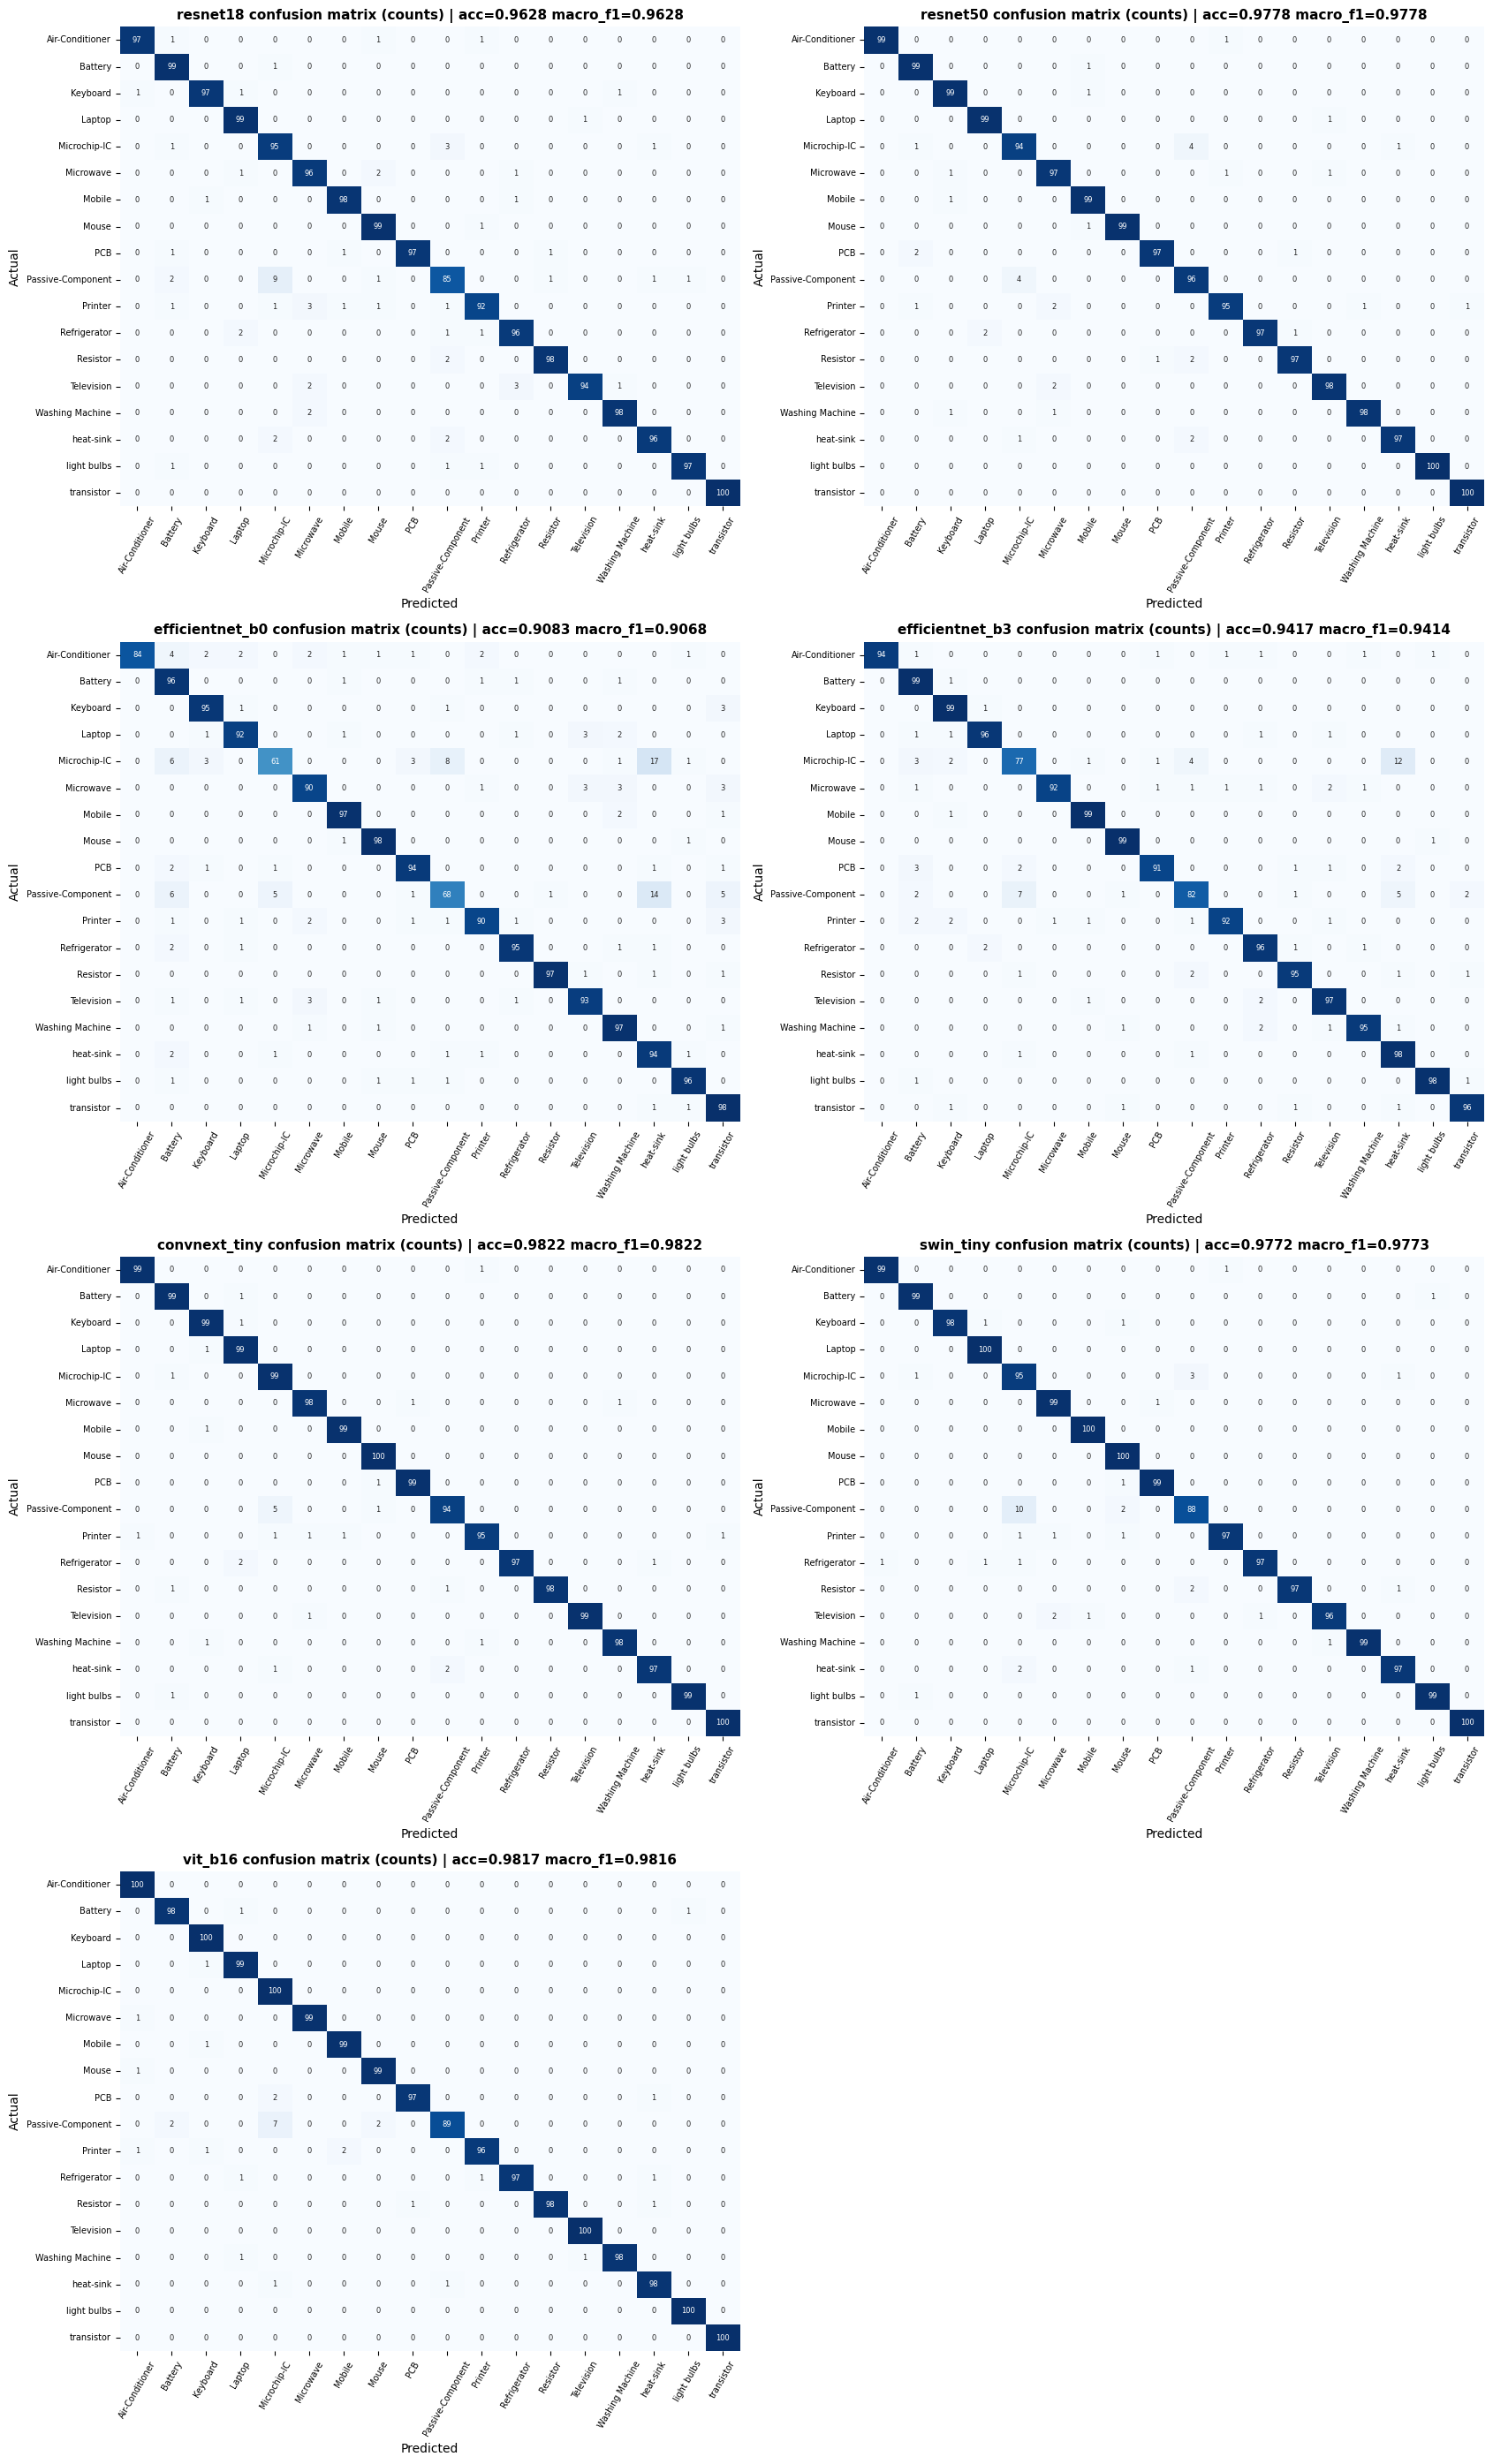

In [10]:
def discover_detailed_confusion_sources():
    detailed = {}
    class_names = None

    # Preferred source: per-architecture detailed results from classification benchmark.
    for results_path in sorted(CLS_DIR.glob("*/deep_results.json")):
        payload = load_json(results_path)
        if not isinstance(payload, dict):
            continue

        if ("confusion_matrix" in payload) or ("confusion_matrix_normalized" in payload):
            detailed[results_path.parent.name] = payload
            if class_names is None and isinstance(payload.get("class_names"), list):
                class_names = payload["class_names"]

    # Fallback source: deep competition payload.
    if not detailed:
        deep_payload = load_json(COMPETE_DIR / "deep_results.json")
        if isinstance(deep_payload, dict):
            for model_name, payload in deep_payload.items():
                if not isinstance(payload, dict):
                    continue
                if ("confusion_matrix" in payload) or ("confusion_matrix_normalized" in payload):
                    detailed[model_name] = payload

    # Class names fallback chain.
    if class_names is None:
        benchmark_summary = load_json(CLS_DIR / "benchmark_summary.json")
        if isinstance(benchmark_summary, dict) and isinstance(benchmark_summary.get("class_names"), list):
            class_names = benchmark_summary["class_names"]

    if class_names is None:
        leaderboard = load_json(COMPETE_DIR / "leaderboard.json")
        if isinstance(leaderboard, dict) and isinstance(leaderboard.get("class_names"), list):
            class_names = leaderboard["class_names"]

    if class_names is None and detailed:
        sample_payload = next(iter(detailed.values()))
        sample_matrix = sample_payload.get("confusion_matrix") or sample_payload.get("confusion_matrix_normalized")
        if isinstance(sample_matrix, list):
            class_names = [f"class_{i}" for i in range(len(sample_matrix))]

    return detailed, class_names


def get_confusion_matrix(payload, normalized=False):
    key = "confusion_matrix_normalized" if normalized else "confusion_matrix"
    matrix = payload.get(key)

    if matrix is None and normalized and payload.get("confusion_matrix") is not None:
        raw = np.array(payload["confusion_matrix"], dtype=float)
        row_sums = raw.sum(axis=1, keepdims=True)
        matrix = np.divide(raw, row_sums, out=np.zeros_like(raw, dtype=float), where=row_sums != 0)

    if matrix is None:
        return None

    return np.array(matrix, dtype=float if normalized else int)


def plot_annotated_confusion_matrices(detailed_payloads, class_names, normalized=False):
    if not detailed_payloads:
        print("No detailed confusion-matrix JSON found.")
        print("Expected one of: models/classification/*/results.json or models/competition/deep_results.json")
        return

    model_names = list(detailed_payloads.keys())
    ncols = 2 if len(model_names) > 1 else 1
    nrows = math.ceil(len(model_names) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(8.5 * ncols, 7.0 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, model_name in zip(axes, model_names):
        payload = detailed_payloads[model_name]
        matrix = get_confusion_matrix(payload, normalized=normalized)

        if matrix is None:
            ax.axis("off")
            ax.set_title(f"{model_name} (matrix unavailable)")
            continue

        n_classes = matrix.shape[0]
        labels = class_names if class_names and len(class_names) == n_classes else [str(i) for i in range(n_classes)]
        annot_size = 6 if n_classes >= 12 else 8
        fmt = ".2f" if normalized else "d"

        sns.heatmap(
            matrix,
            ax=ax,
            cmap="Blues",
            annot=True,
            fmt=fmt,
            cbar=False,
            xticklabels=labels,
            yticklabels=labels,
            annot_kws={"size": annot_size},
        )

        metrics = payload.get("metrics", {}) if isinstance(payload, dict) else {}
        accuracy = metrics.get("accuracy") if isinstance(metrics, dict) else None
        macro_f1 = metrics.get("macro_f1") if isinstance(metrics, dict) else None

        suffix = ""
        if isinstance(accuracy, (int, float)) and isinstance(macro_f1, (int, float)):
            suffix = f" | acc={accuracy:.4f} macro_f1={macro_f1:.4f}"

        matrix_label = "normalized" if normalized else "counts"
        ax.set_title(f"{model_name} confusion matrix ({matrix_label}){suffix}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.tick_params(axis="x", labelrotation=60, labelsize=7)
        ax.tick_params(axis="y", labelrotation=0, labelsize=7)

    for ax in axes[len(model_names):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


detailed_confusion_payloads, confusion_class_names = discover_detailed_confusion_sources()
print(f"detailed confusion sources found: {len(detailed_confusion_payloads)}")

# Set to True if you want normalized [0, 1] matrices instead of integer counts.
SHOW_NORMALIZED_CM = False
plot_annotated_confusion_matrices(
    detailed_confusion_payloads,
    confusion_class_names,
    normalized=SHOW_NORMALIZED_CM,
)

In [11]:
ann_metrics

{'model': 'HazardAnn',
 'features': ['comp_enc',
  'age_years',
  'weight_kg',
  'contains_lithium',
  'contains_lead',
  'contains_mercury',
  'contains_cadmium',
  'contains_cfc',
  'recyclable',
  'mat_enc',
  'wc_enc',
  'cond_enc',
  'reg_enc',
  'disp_enc'],
 'n_samples': {'train': 1890, 'val': 405, 'test': 405},
 'regression_metrics': {'mae': 2.7521,
  'rmse': 3.7666,
  'r2': 0.9859,
  'mape': 7.3136},
 'classification_metrics': {'hazard_class_accuracy': 0.9556,
  'hazard_macro_f1': 0.9249},
 'classification_report': {'HIGH': {'precision': 0.9778761061946902,
   'recall': 0.9822222222222222,
   'f1-score': 0.9800443458980045,
   'support': 225.0},
  'MEDIUM': {'precision': 0.8979591836734694,
   'recall': 0.7719298245614035,
   'f1-score': 0.8301886792452831,
   'support': 57.0},
  'LOW': {'precision': 0.9384615384615385,
   'recall': 0.991869918699187,
   'f1-score': 0.9644268774703557,
   'support': 123.0},
  'accuracy': 0.9555555555555556,
  'macro avg': {'precision': 0.93809

In [12]:
clustering_metrics

{'n_clusters': 3,
 'total_samples': 27560,
 'silhouette_score': 0.0783119723200798,
 'davies_bouldin_index': 4.934664381379223,
 'calinski_harabasz_index': 1034.5625742919517,
 'adjusted_rand_index': 0.0757409779282442,
 'normalized_mutual_info': 0.230084274431711,
 'cluster_sizes': {'0': 5801, '1': 15968, '2': 5791}}

In [13]:
def discover_images(base_dir: Path):
    if not base_dir.exists():
        return []
    return sorted(
        [path for path in base_dir.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTS],
        key=lambda path: str(path.relative_to(PROJECT_ROOT)).lower(),
    )

classification_graphs = [
    path for path in discover_images(CLS_DIR / "graphs")
    if path.name.lower() != "confusion_matrices_18cls.png"
]

figure_groups = {
    "Classification": classification_graphs,
    "ANN Hazard Modeling": discover_images(ANN_DIR / "graphs") + [
        path for path in discover_images(ANN_DIR)
        if path.parent == ANN_DIR
    ],
    "Clustering": discover_images(CLUSTER_DIR / "graphs") + [
        path for path in discover_images(CLUSTER_DIR)
        if path.parent == CLUSTER_DIR
    ],
}

for group_name, files in figure_groups.items():
    deduped = []
    seen = set()
    for path in files:
        key = str(path.resolve())
        if key not in seen:
            deduped.append(path)
            seen.add(key)
    figure_groups[group_name] = deduped
    print(f"{group_name}: {len(deduped)} figure(s)")
    for path in deduped:
        print(" -", path.relative_to(PROJECT_ROOT))

print("\nconfusion_matrices_18cls.png is excluded from image gallery")
print("because the notebook now renders annotated confusion matrices directly from JSON.")

Classification: 4 figure(s)
 - models\classification\graphs\gradcam_all_classes.png
 - models\classification\graphs\per_class_f1_comparison.png
 - models\classification\graphs\training_curves.png
 - models\classification\graphs\training_curves_18cls.png
ANN Hazard Modeling: 0 figure(s)
Clustering: 0 figure(s)

confusion_matrices_18cls.png is excluded from image gallery
because the notebook now renders annotated confusion matrices directly from JSON.


In [14]:
def show_graph(path: Path, title: str | None = None) -> None:
    if not path.exists():
        print(f"missing: {path.name}")
        return

    image = Image.open(path)
    width, height = image.size
    plt.figure(figsize=(min(18, max(8, width / 110)), min(12, max(4, height / 110))))
    plt.imshow(image)
    plt.title(title or path.name, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()


Classification


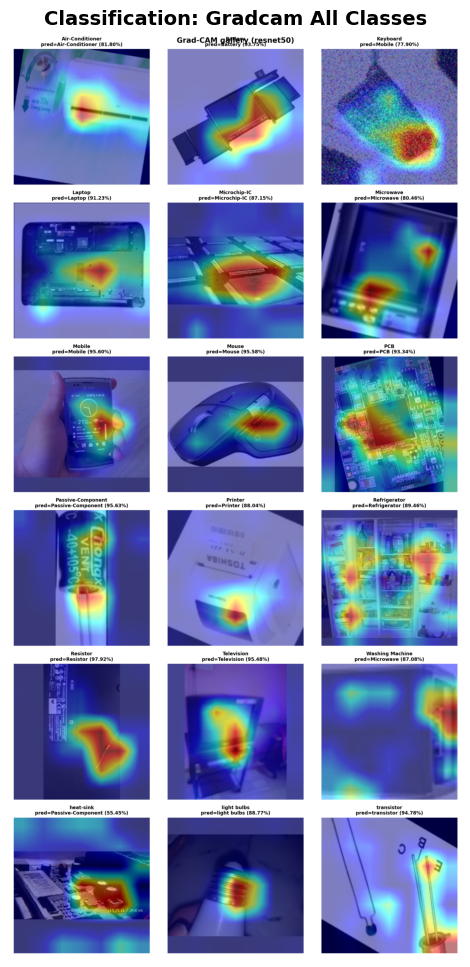

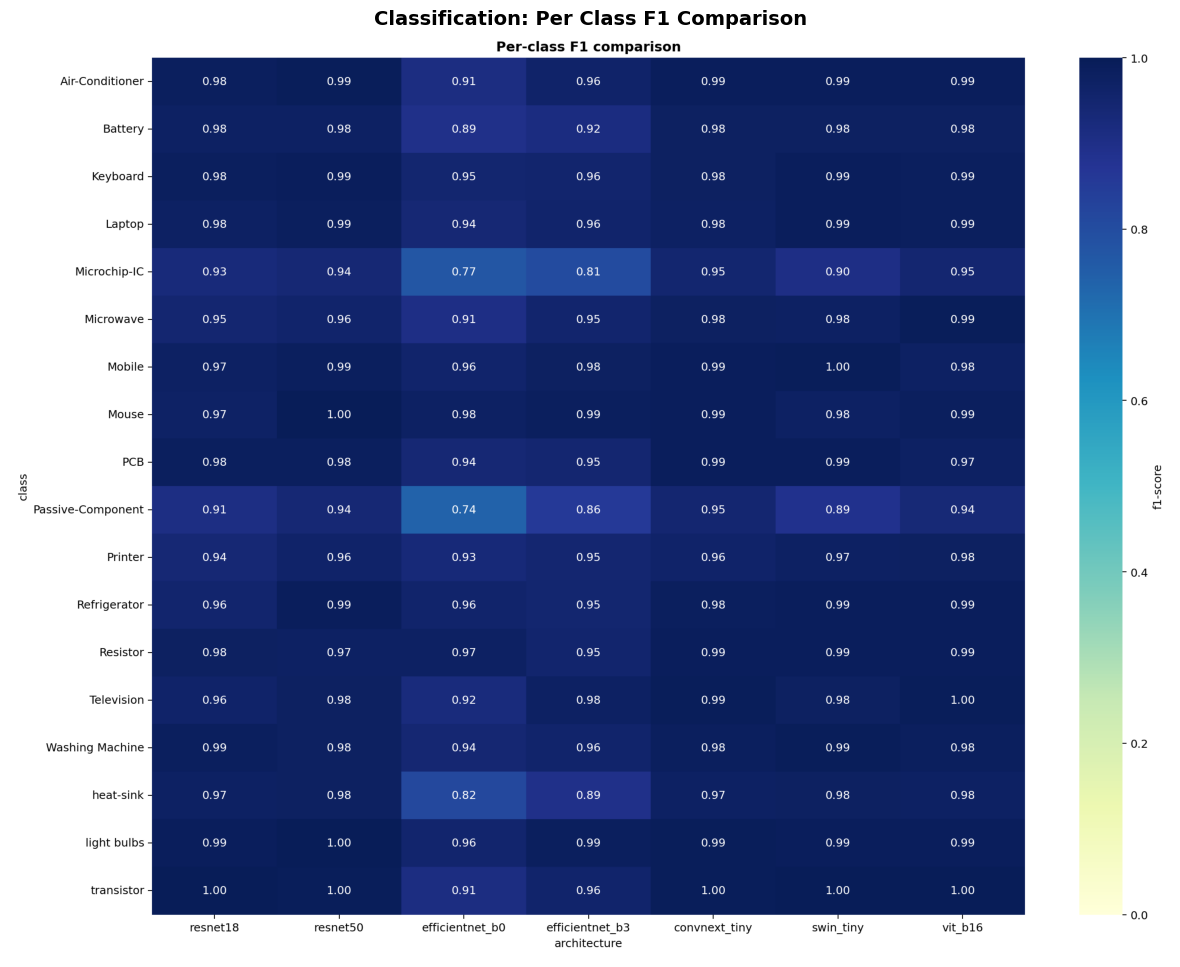

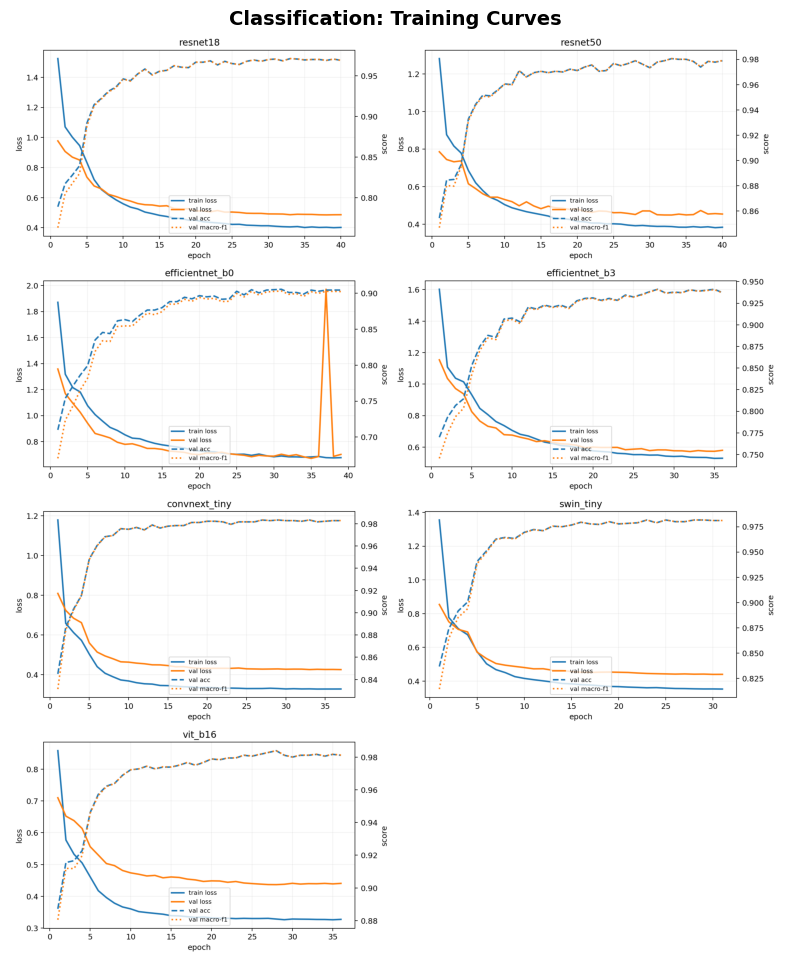

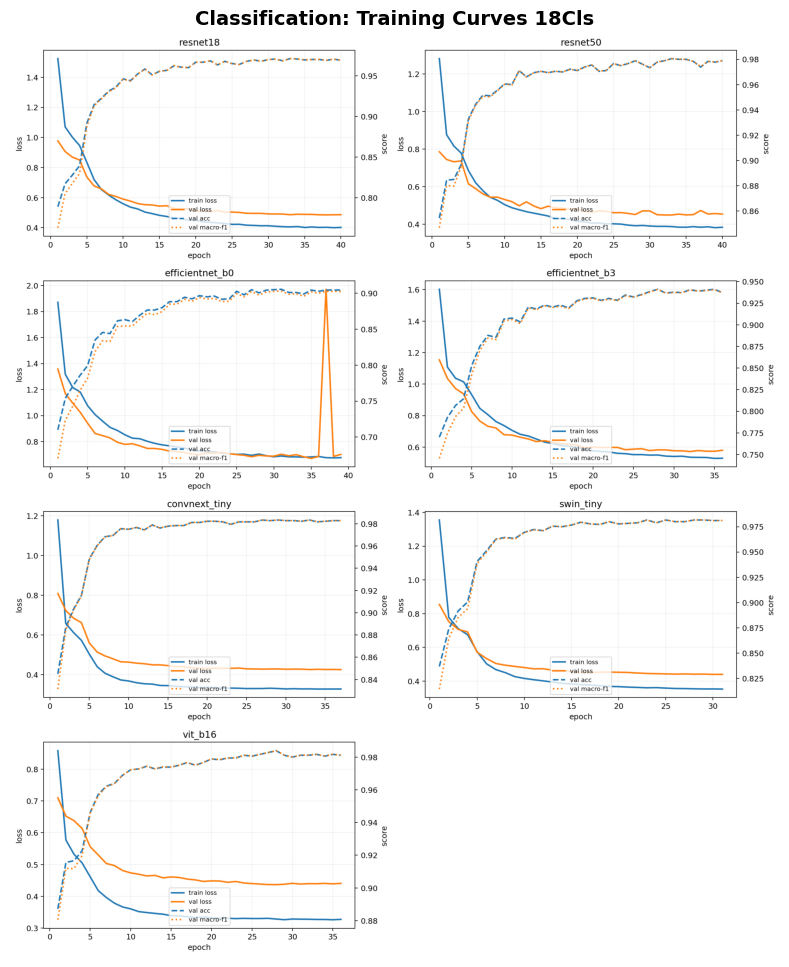


ANN Hazard Modeling
no saved figures found

Clustering
no saved figures found


In [15]:
for group_name, files in figure_groups.items():
    print("\n" + "=" * 80)
    print(group_name)
    print("=" * 80)
    if not files:
        print("no saved figures found")
        continue
    for path in files:
        show_graph(path, f"{group_name}: {path.stem.replace('_', ' ').title()}")